# NB12 — Visualisasi Sebaran Cluster & Noise (Hasil Final)

**Tujuan:** menjawab masukan penguji seminar hasil — menampilkan sebaran titik data
hasil clustering (terkelompok vs noise) secara visual, dan memastikan foto asli di
balik tiap titik noise bisa ditelusuri.

**PENTING — notebook ini HANYA MEMBACA output yang sudah ada.** Tidak ada pipeline
NB01/NB05/NB10/NB11 yang dijalankan ulang, dan tidak ada apa pun yang ditulis ke
`output_nb01/`, `output_nb05/`, `output_nb10/`, atau `output_nb11/`. Semua output
notebook ini masuk ke folder baru `output_nb12/` agar seluruh angka Bab IV
(15.248 wajah, DBCV 0,6588, 139 klaster, dst.) tidak tersentuh.

**Input:**
- `output_nb11/skenario_e_results.pkl` → `labels_E` (label final, 14.790 wajah inlier)
  dan `meta` (metadata paralel: `photo_path`, `bbox`)
- `output_nb10/umap_coords_inlier.npy` → `X_umap` (koordinat 30-dim, ruang tempat
  HDBSCAN benar-benar dijalankan)

**Output:** 4 gambar PNG ke `output_nb12/`.

**Catatan metodologis wajib dibaca sebelum menafsirkan gambar di bawah:** proyeksi
2D pada notebook ini HANYA untuk visualisasi — bukan dasar penentuan cluster. Warna
tiap titik berasal dari label yang sudah dihitung sebelumnya di ruang 30-dim asli
(`labels_E`, hasil Two-Pass HDBSCAN + GLOSH + Approximate Predict). Jarak antar
klaster dan kepadatan visual di plot 2D TIDAK boleh dibaca sebagai ukuran kuantitatif
kualitas clustering — itu artefak proyeksi (UMAP tidak menjaga jarak global maupun
kepadatan relatif, hanya ketetanggaan lokal). Bukti kuantitatif kualitas clustering
adalah metrik di Tabel IV.6 (DBCV, Silhouette, DBI), dihitung di ruang 30-dim asli,
bukan dari plot ini.

## 0. Setup

In [13]:
!pip install umap-learn hdbscan pillow-heif rawpy opencv-python-headless -q

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pickle
from pathlib import Path
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import umap
import hdbscan

from pillow_heif import register_heif_opener
register_heif_opener()

print('Setup OK.')

Mounted at /content/drive
Setup OK.


## 1. Muat output NB10 & NB11 (baca saja)

In [14]:
BASE       = Path("/content/drive/MyDrive/OTW S.KOM/Embeddings")
NB10_DIR   = BASE / "output_nb10"
NB11_DIR   = BASE / "output_nb11"
OUTPUT_DIR = BASE / "output_nb12"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

X_umap = np.load(NB10_DIR / "umap_coords_inlier.npy")

with open(NB11_DIR / "skenario_e_results.pkl", "rb") as f:
    results_E = pickle.load(f)

labels_E = results_E["labels_E"]
meta     = results_E["meta"]          # paralel dgn labels_E & X_umap

assert len(labels_E) == len(meta) == X_umap.shape[0], "Indeks tidak selaras!"

n_noise_E    = int((labels_E == -1).sum())
n_cluster_E  = len(set(labels_E)) - (1 if -1 in labels_E else 0)

print(f"X_umap        : {X_umap.shape}")
print(f"labels_E      : {len(labels_E):,} titik")
print(f"Jumlah cluster: {n_cluster_E}")
print(f"Noise (S1)    : {n_noise_E}")
print()
print("Kontrol silang (harus cocok Tabel IV.6): 139 klaster, 60 noise")

X_umap        : (14790, 30)
labels_E      : 14,790 titik
Jumlah cluster: 139
Noise (S1)    : 60

Kontrol silang (harus cocok Tabel IV.6): 139 klaster, 60 noise


## 2. Proyeksi 2D (visualisasi saja)

Proyeksi dijalankan dari `X_umap` (30-dim, ruang tempat HDBSCAN dijalankan) — BUKAN
dari embedding 512-dim mentah seperti pada NB03/NB05. Alasannya: ini proyeksi paling
langsung dari ruang yang sama persis dilihat HDBSCAN, sehingga tata letak 2D yang
dihasilkan paling relevan menggambarkan struktur yang benar-benar dipakai algoritma
untuk membentuk cluster.

In [15]:
reducer_viz = umap.UMAP(
    n_components=2,
    random_state=42,
    n_jobs=1,        # n_jobs=1 wajib berpasangan dgn random_state utk reproducibility
    verbose=True,
)
emb_2d = reducer_viz.fit_transform(X_umap)
print(f"emb_2d shape: {emb_2d.shape}")

UMAP(n_jobs=1, random_state=42, verbose=True)
Thu Aug 13 17:08:23 2026 Construct fuzzy simplicial set
Thu Aug 13 17:08:23 2026 Finding Nearest Neighbors
Thu Aug 13 17:08:23 2026 Building RP forest with 11 trees
Thu Aug 13 17:08:23 2026 NN descent for 14 iterations
	 1  /  14
	 2  /  14
	Stopping threshold met -- exiting after 2 iterations
Thu Aug 13 17:08:24 2026 Finished Nearest Neighbor Search
Thu Aug 13 17:08:24 2026 Construct embedding


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 2000 with accuracies 
[3.94841793e-15 4.71334182e-07 5.36308535e-07 2.99298929e-05]
not reaching the requested tolerance 1.773238182067871e-06.
Use iteration 535 instead with accuracy 
5.172498701474591e-06.

  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[2.36943478e-15 5.54350679e-07 7.17855718e-07 1.94177884e-05]
not reaching the requested tolerance 1.773238182067871e-06.
  _, diffusion_map = lobpcg(


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Thu Aug 13 17:08:56 2026 Finished embedding
emb_2d shape: (14790, 2)


## 3. Gambar 1 — Sebaran Final: Cluster vs Noise

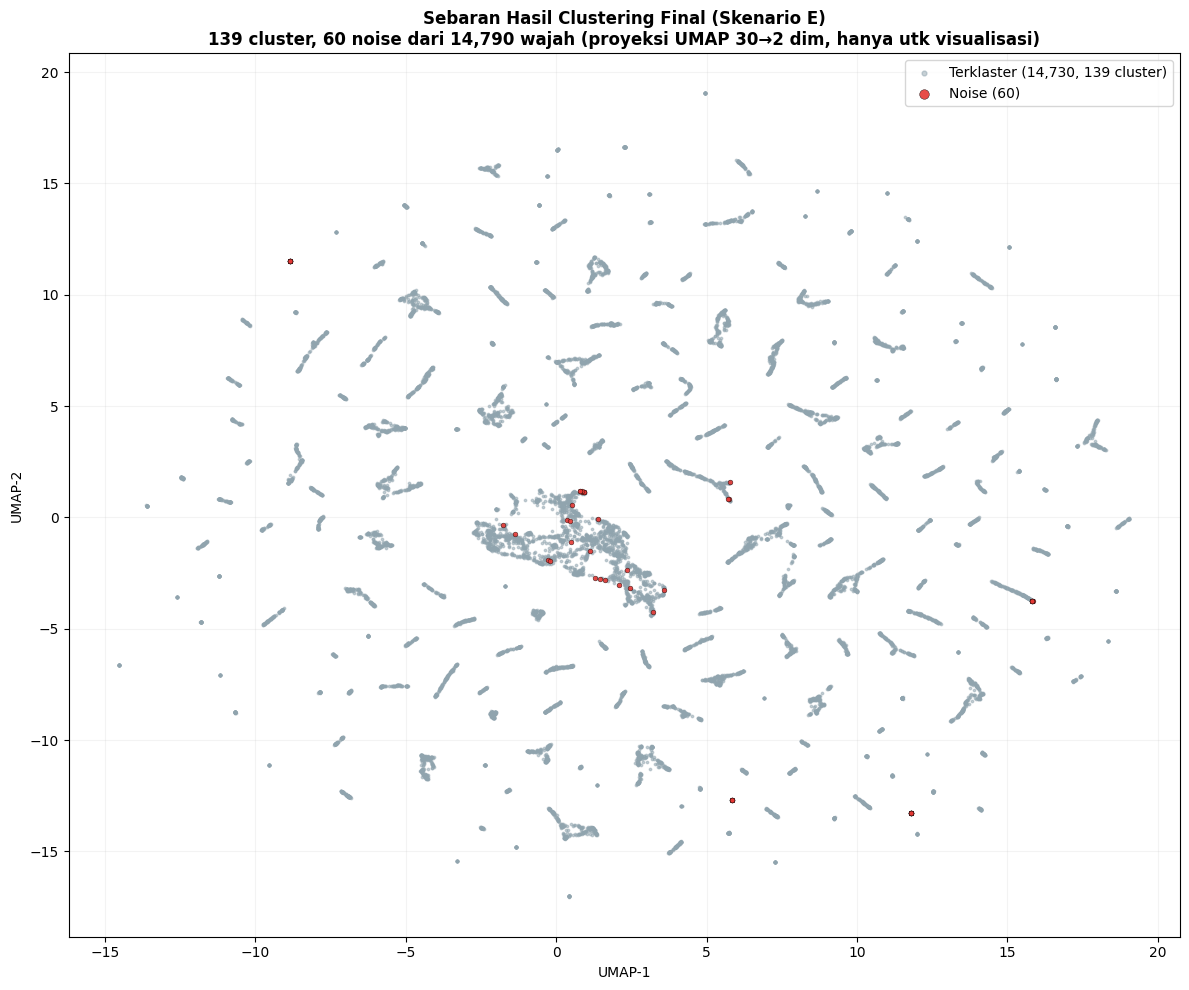

In [16]:
mask_noise = labels_E == -1
mask_clust = labels_E >= 0

fig, ax = plt.subplots(figsize=(12, 10))

# Terklaster — satu warna netral. 139 cluster tidak realistis dibedakan
# per-warna (colormap tab20 cuma 20 warna, akan tabrakan tiap 20 cluster
# dan menyesatkan secara visual — beberapa cluster berbeda jadi kelihatan
# menyatu jadi satu blob padahal cuma kebetulan sewarna).
ax.scatter(emb_2d[mask_clust, 0], emb_2d[mask_clust, 1],
           c='#90A4AE', s=3, alpha=0.5, zorder=1, rasterized=True,
           label=f'Terklaster ({int(mask_clust.sum()):,}, {n_cluster_E} cluster)')

# Noise — digambar terakhir, di atas (zorder tinggi), lebih besar & merah
ax.scatter(emb_2d[mask_noise, 0], emb_2d[mask_noise, 1],
           c='#E53935', s=12, alpha=0.9, zorder=3,
           edgecolors='black', linewidths=0.3,
           label=f'Noise ({n_noise_E})')

ax.set_title(
    f"Sebaran Hasil Clustering Final (Skenario E)\n"
    f"{n_cluster_E} cluster, {n_noise_E} noise dari {len(labels_E):,} wajah "
    f"(proyeksi UMAP 30\u21922 dim, hanya utk visualisasi)",
    fontsize=12, fontweight='bold'
)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=2, fontsize=10, loc='best')
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gambar1_sebaran_final.png", dpi=150, bbox_inches='tight')
plt.show()

## 3b. Diagnostik — apakah massa padat di tengah 1 cluster atau beberapa?

Gambar 1 menunjukkan satu massa jauh lebih besar/padat dibanding streak-streak
kecil lain. Sebelum dipakai di skripsi, ini diverifikasi: N cluster terbesar
disorot warna berbeda-beda. Kalau massa itu didominasi 1-2 warna \u2192 memang
satu/dua identitas dengan foto sangat banyak (wajar \u2014 baseline NB05 mencatat
rentang ukuran cluster 51 s.d. 1203 foto). Kalau berisi banyak warna berdempetan
\u2192 beberapa cluster berbeda yang kebetulan bertetangga di proyeksi 2D.

In [ ]:
from collections import Counter

N_TOP = 8
cluster_sizes = Counter(labels_E[labels_E >= 0].tolist())
sizes_sorted = sorted(cluster_sizes.items(), key=lambda x: -x[1])

print(f"Ukuran cluster \u2014 min: {min(cluster_sizes.values())}, "
      f"max: {max(cluster_sizes.values())}, "
      f"mean: {np.mean(list(cluster_sizes.values())):.1f}, "
      f"median: {np.median(list(cluster_sizes.values())):.0f}")
print(f"\n{N_TOP} cluster terbesar:")
for cid, sz in sizes_sorted[:N_TOP]:
    print(f"  cluster {cid:4d} : {sz:4d} wajah")

top_ids = [cid for cid, _ in sizes_sorted[:N_TOP]]
top_cmap = plt.colormaps.get_cmap('tab10')

fig, ax = plt.subplots(figsize=(12, 10))

mask_other = mask_clust & ~np.isin(labels_E, top_ids)
ax.scatter(emb_2d[mask_other, 0], emb_2d[mask_other, 1],
           c='#CFD8DC', s=3, alpha=0.4, zorder=1, rasterized=True)

for i, cid in enumerate(top_ids):
    m = labels_E == cid
    ax.scatter(emb_2d[m, 0], emb_2d[m, 1], c=[top_cmap(i)],
               s=6, alpha=0.85, zorder=2, rasterized=True,
               label=f'Cluster {cid} (n={cluster_sizes[cid]})')

ax.scatter(emb_2d[mask_noise, 0], emb_2d[mask_noise, 1],
           c='#E53935', s=8, alpha=0.5, zorder=1.5)

ax.set_title(
    f"Diagnostik: {N_TOP} Cluster Terbesar Disorot\n"
    f"1\u20132 warna mendominasi massa pusat = cluster besar wajar. "
    f"Banyak warna berdempetan = beberapa cluster bertetangga.",
    fontsize=11, fontweight='bold'
)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=2, fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gambar1b_diagnostik_cluster_besar.png", dpi=150, bbox_inches='tight')
plt.show()

## 3c. Diagnostik lanjutan — det_score & ukuran wajah di cluster besar

User sudah memeriksa langsung isi cluster terbesar (sample visual) dan menemukan
mayoritas fotonya blur berat / gelap tak jelas / sama sekali bukan wajah yang bisa
dikenali \u2014 bukan sekadar kualitas rendah, tapi pola yang mengarah ke cluster
**spurious** (kontaminasi), bukan satu identitas asli.

Mekanisme yang diduga: embedding wajah pada input sangat terdegradasi cenderung
"kolaps" ke wilayah generik di ruang 512-dim (bukan ke wilayah identitas manapun)
\u2014 sehingga banyak deteksi kualitas sangat rendah dari orang BERBEDA (bahkan
kemungkinan salah-deteksi non-wajah) bisa saling berdekatan bukan karena identitas
sama, tapi karena sama-sama "rusak" dengan cara serupa. HDBSCAN tidak tahu alasan
kedekatan \u2014 ia hanya mengukur densitas, sehingga wilayah kolaps yang cukup
padat diperlakukan sebagai cluster sah. LOF pun tidak menangkap ini: LOF mendeteksi
densitas lokal RENDAH, sedangkan titik-titik terdegradasi ini justru berkumpul
padat satu sama lain \u2014 sehingga terlihat "normal" bagi LOF, bukan outlier.

Sel ini menguji jejak tidak langsungnya: apakah cluster ini condong ke det_score
rendah (dekat lantai `DET_THRESH=0,35`) dan bbox (ukuran wajah) kecil dibanding
rata-rata dataset?

In [ ]:
CLUSTER_ID = int(sizes_sorted[0][0])  # cluster terbesar (otomatis, dari sel 3b)
idx_c = np.where(labels_E == CLUSTER_ID)[0]

det_scores_c   = np.array([meta[i]['det_score'] for i in idx_c])
det_scores_all = np.array([m['det_score'] for m in meta])

def bbox_area(m):
    x1, y1, x2, y2 = m['bbox']
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)

bbox_areas_c   = np.array([bbox_area(meta[i]) for i in idx_c])
bbox_areas_all = np.array([bbox_area(m) for m in meta])

print(f"Cluster terbesar: #{CLUSTER_ID}  ({len(idx_c):,} wajah, "
      f"{len(idx_c)/len(labels_E)*100:.1f}% dari seluruh {len(labels_E):,} wajah inlier)")
print()
print("=== det_score ===")
print(f"  Cluster {CLUSTER_ID} : min={det_scores_c.min():.3f}  mean={det_scores_c.mean():.3f}  "
      f"median={np.median(det_scores_c):.3f}  max={det_scores_c.max():.3f}")
print(f"  Semua data (inlier) : min={det_scores_all.min():.3f}  mean={det_scores_all.mean():.3f}  "
      f"median={np.median(det_scores_all):.3f}  max={det_scores_all.max():.3f}")
print()
print("=== sisi wajah \u2248 \u221a(luas bbox), piksel ===")
sisi_c, sisi_all = np.sqrt(bbox_areas_c), np.sqrt(bbox_areas_all)
print(f"  Cluster {CLUSTER_ID} : mean={sisi_c.mean():.0f}  median={np.median(sisi_c):.0f}")
print(f"  Semua data (inlier) : mean={sisi_all.mean():.0f}  median={np.median(sisi_all):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(det_scores_all, bins=30, alpha=0.5, density=True, label='Semua data')
axes[0].hist(det_scores_c, bins=30, alpha=0.7, density=True, color='#E53935',
             label=f'Cluster {CLUSTER_ID}')
axes[0].axvline(0.35, color='black', linestyle='--', linewidth=1, label='DET_THRESH=0,35')
axes[0].set_xlabel('det_score'); axes[0].set_title('Distribusi det_score'); axes[0].legend(fontsize=8)

axes[1].hist(sisi_all, bins=30, alpha=0.5, density=True, label='Semua data')
axes[1].hist(sisi_c, bins=30, alpha=0.7, density=True, color='#E53935',
             label=f'Cluster {CLUSTER_ID}')
axes[1].set_xlabel('sisi wajah (piksel)'); axes[1].set_title('Distribusi ukuran wajah'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"diagnostik_detscore_bbox_cluster{CLUSTER_ID}.png", dpi=150, bbox_inches='tight')
plt.show()

## 3d. Cross-check ground truth \u2014 1 identitas atau kontaminasi banyak orang?

Ini pembuktian paling definitif. `face_labels_verified.csv` (hasil
`LABEL_Cluster_Verification.ipynb`, 75 identitas, 10.174 wajah terverifikasi
manusia) dicocokkan ke tiap wajah di cluster ini via `global_index`. Perlu memuat
ulang `idx_inlier` dari `output_nb10/` \u2014 array ini TIDAK tersimpan di
`skenario_e_results.pkl` yang sudah dimuat sebelumnya.

- **1 identitas unik** \u2192 cluster sah, cuma satu orang dengan sangat banyak
  foto kualitas rendah (masuk akal, tidak masalah).
- **>1 identitas unik** \u2192 cluster ini **spurious/kontaminasi terkonfirmasi**
  \u2014 harus diungkap sebagai keterbatasan penelitian di Bab IV/V, bukan
  ditutupi.

In [ ]:
import csv as _csv

with open(NB10_DIR / "skenario_d_results.pkl", "rb") as f:
    _results_d = pickle.load(f)
idx_inlier_global = _results_d["idx_inlier"]  # posisi-inlier -> global_index asli (metadata_labeled.pkl)

gt_path = BASE / "output_labeling" / "face_labels_verified.csv"

if not gt_path.exists():
    print(f"File ground truth tidak ditemukan di {gt_path} \u2014 lewati cross-check ini.")
else:
    gid_to_identity = {}
    with open(gt_path, newline='', encoding='utf-8') as f:
        for row in _csv.DictReader(f):
            gid_to_identity[int(row['global_index'])] = row['identity_id']

    identities_in_cluster = []
    for local_i in idx_c:
        gidx = int(idx_inlier_global[local_i])
        if gidx in gid_to_identity:
            identities_in_cluster.append(gid_to_identity[gidx])

    n_verified = len(identities_in_cluster)
    print(f"Dari {len(idx_c):,} wajah di cluster {CLUSTER_ID}, "
          f"{n_verified:,} ({n_verified/len(idx_c)*100:.1f}%) punya ground truth terverifikasi.")

    if n_verified == 0:
        print("Tidak ada wajah di cluster ini yang masuk 10.174 wajah terverifikasi \u2014 "
              "tidak bisa disimpulkan lewat ground truth, cukup andalkan bukti visual + det_score/bbox.")
    else:
        counts = Counter(identities_in_cluster)
        print(f"\nJumlah identitas BERBEDA dalam cluster ini: {len(counts)}")
        print("Rincian (identity_id : jumlah wajah):")
        for ident, n in counts.most_common(15):
            print(f"  {ident} : {n}")
        if len(counts) > 15:
            print(f"  ... dan {len(counts)-15} identitas lainnya")

        if len(counts) == 1:
            print(f"\n\u2713 SATU identitas \u2014 cluster {CLUSTER_ID} sah, cuma orang yang sangat "
                  f"sering difoto dengan banyak foto kualitas rendah.")
        else:
            print(f"\n\u26a0 CAMPURAN {len(counts)} identitas berbeda \u2014 cluster {CLUSTER_ID} "
                  f"SPURIOUS/kontaminasi terkonfirmasi, BUKAN satu orang.")

## 3e. Pembanding visual \u2014 cluster terbesar vs cluster terbesar kedua

Kalau cluster kedua terlihat jelas/tajam sementara cluster pertama tidak, ini
penguat bahwa temuan di atas spesifik pada satu cluster tertentu \u2014 bukan pola
umum di seluruh dataset (yang berarti pipeline secara keseluruhan tetap valid,
cuma satu cluster ini yang bermasalah).

In [ ]:
CLUSTER_ID_2 = int(sizes_sorted[1][0])
idx_c2 = np.where(labels_E == CLUSTER_ID_2)[0]
print(f"Cluster pembanding: #{CLUSTER_ID_2} ({len(idx_c2):,} wajah)")

MAX_SHOW = 32
rng = np.random.default_rng(seed=42)

def _sample(idx_arr):
    if len(idx_arr) > MAX_SHOW:
        return np.sort(rng.choice(idx_arr, size=MAX_SHOW, replace=False))
    return idx_arr

show_1 = _sample(idx_c)
show_2 = _sample(idx_c2)

fig1 = render_faces(show_1.tolist(), ranks=show_1.tolist(), cols=8,
                     title=f"Cluster {CLUSTER_ID} (terbesar, n={len(idx_c):,}) \u2014 sampel {len(show_1)}")
fig1.savefig(OUTPUT_DIR / f"pembanding_cluster{CLUSTER_ID}.png", dpi=150, bbox_inches='tight')
plt.show()

fig2 = render_faces(show_2.tolist(), ranks=show_2.tolist(), cols=8,
                     title=f"Cluster {CLUSTER_ID_2} (terbesar ke-2, n={len(idx_c2):,}) \u2014 sampel {len(show_2)}")
fig2.savefig(OUTPUT_DIR / f"pembanding_cluster{CLUSTER_ID_2}.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Gambar 2 — Sebelum vs Sesudah Refinement (S0 vs S1)

Pass-1 (S0) dihitung ulang di sini dengan konfigurasi yang identik dengan cell
konfigurasi `nb11_lof2.ipynb` (`MCS_PASS1=15, MS=10`) — pemenang grid search
`NB10b_Grid_mcs_ms_UMAP30.ipynb` (DBCV=0,8391). Karena HDBSCAN deterministik untuk
input dan parameter yang sama, hasil ini WAJIB identik dengan hasil pass-1 yang
sudah tercatat (123 cluster, 450 noise) — sel di bawah memverifikasi ini secara
eksplisit sebelum plot dibuat.

In [17]:
clusterer_pass1 = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)
labels_S0 = clusterer_pass1.fit_predict(X_umap)

n_noise_S0   = int((labels_S0 == -1).sum())
n_cluster_S0 = len(set(labels_S0)) - (1 if -1 in labels_S0 else 0)

print(f"S0 (pass-1 saja) : {n_cluster_S0} cluster, {n_noise_S0} noise")
print(f"S1 (final)        : {n_cluster_E} cluster, {n_noise_E} noise")

assert n_cluster_S0 == 123 and n_noise_S0 == 450, (
    "Hasil pass-1 TIDAK cocok dgn catatan NB10b (123 cluster/450 noise) — "
    "kemungkinan X_umap yang dimuat berbeda dari yang dipakai nb11_lof2. "
    "JANGAN lanjut sebelum ini diselidiki."
)
print("\u2713 Cocok dgn baris pemenang NB10b — X_umap terverifikasi konsisten.")

S0 (pass-1 saja) : 123 cluster, 450 noise
S1 (final)        : 139 cluster, 60 noise
✓ Cocok dgn baris pemenang NB10b — X_umap terverifikasi konsisten.


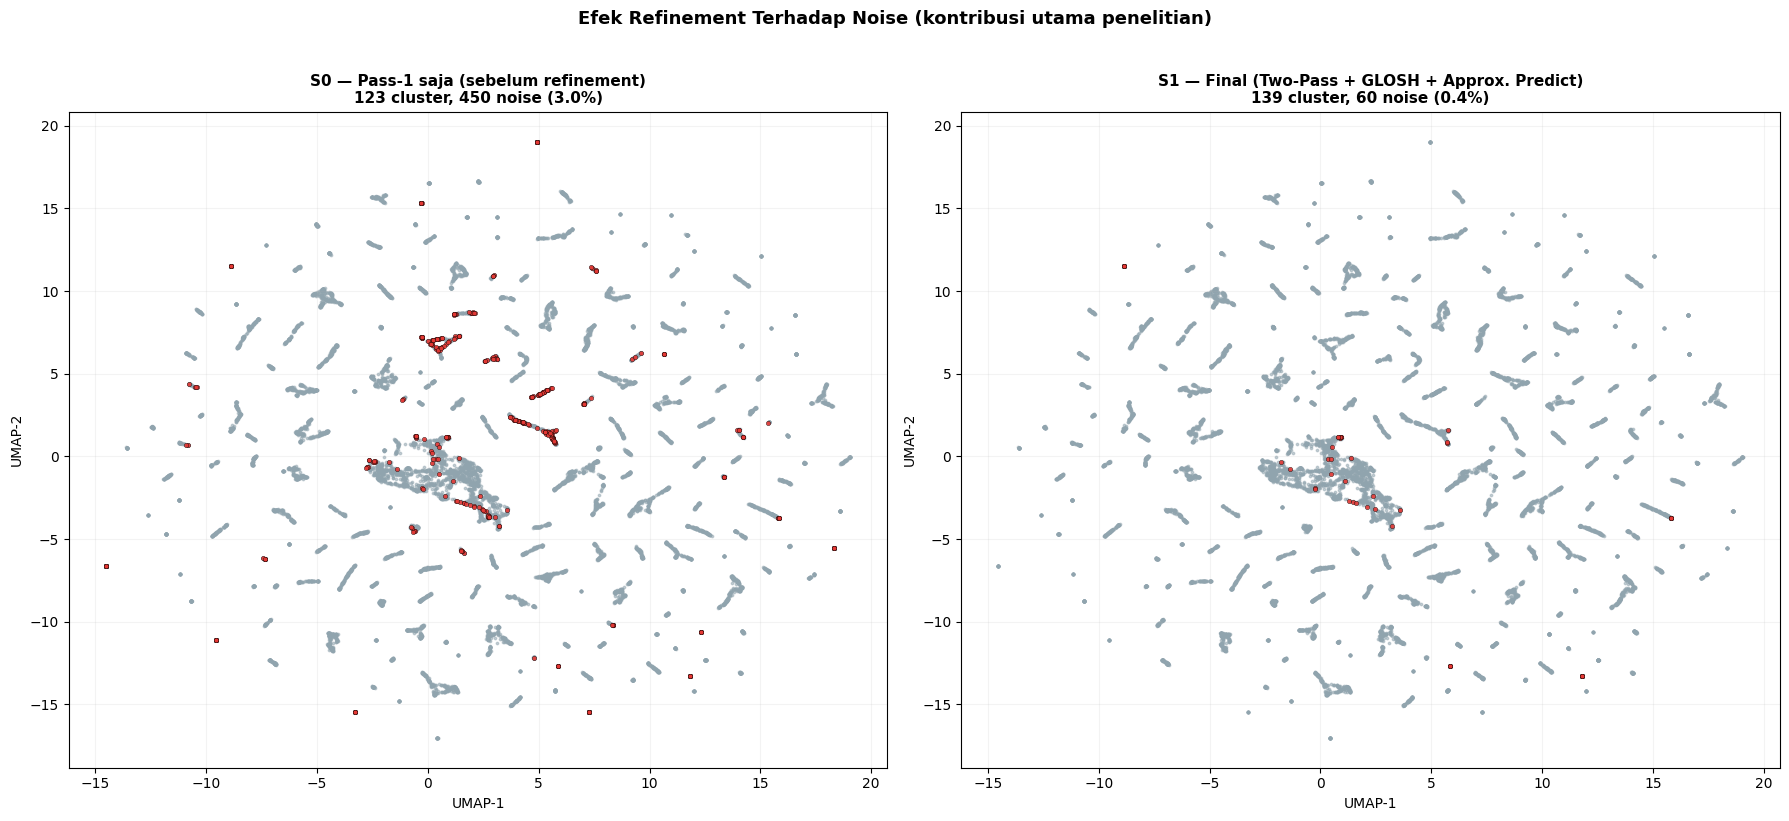

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, labels_x, title, n_c, n_n in [
    (axes[0], labels_S0, "S0 \u2014 Pass-1 saja (sebelum refinement)", n_cluster_S0, n_noise_S0),
    (axes[1], labels_E,  "S1 \u2014 Final (Two-Pass + GLOSH + Approx. Predict)", n_cluster_E, n_noise_E),
]:
    m_noise = labels_x == -1
    m_clust = labels_x >= 0
    ax.scatter(emb_2d[m_clust, 0], emb_2d[m_clust, 1],
               c='#90A4AE', s=3, alpha=0.5, zorder=1, rasterized=True)
    ax.scatter(emb_2d[m_noise, 0], emb_2d[m_noise, 1],
               c='#E53935', s=10, alpha=0.9, zorder=3,
               edgecolors='black', linewidths=0.3)
    ax.set_title(f"{title}\n{n_c} cluster, {n_n} noise ({n_n/len(labels_x)*100:.1f}%)",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    ax.grid(alpha=0.15)

fig.suptitle("Efek Refinement Terhadap Noise (kontribusi utama penelitian)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "gambar2_sebelum_sesudah_refinement.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Helper baca foto & crop wajah

Dipakai ulang dari `LABEL_Cluster_Verification.ipynb` (repo `fotoQu-faceEnhancement`)
— satu-satunya implementasi di kedua repo yang menangani RAW kamera dan HEIC iPhone,
bukan hanya JPG. Dua perbaikan diterapkan dibanding versi asal:
1. `render_faces` di sini memakai `set_xticks([])`/`set_yticks([])`, BUKAN
   `ax.axis("off")` — versi asal memanggil `axis("off")` untuk semua axis sebelum
   loop, sehingga border highlight tidak pernah tampil.
2. Tidak ada `cv2.cvtColor(..., COLOR_BGR2RGB)` ganda pada keluaran `thumb()` —
   `thumb()` sudah mengembalikan RGB; versi `show_review_gallery` di notebook asal
   mengonversi ulang sehingga wajah tampak kebiruan. Di sini tidak diulang.

In [19]:
_PHOTO_CACHE = OrderedDict()
_CACHE_CAP = 64
RAW_EXTS = {'.raf', '.cr2', '.nef', '.arw', '.dng', '.rw2', '.orf'}

def imread_any(p):
    if p in _PHOTO_CACHE:
        _PHOTO_CACHE.move_to_end(p)
        return _PHOTO_CACHE[p]
    img = cv2.imread(p)
    if img is None:
        ext = Path(p).suffix.lower()
        try:
            if ext in RAW_EXTS:
                import rawpy
                with rawpy.imread(p) as raw:
                    img = cv2.cvtColor(raw.postprocess(), cv2.COLOR_RGB2BGR)
            else:
                from PIL import Image
                img = cv2.cvtColor(np.array(Image.open(p).convert("RGB")), cv2.COLOR_RGB2BGR)
        except Exception:
            img = None
    _PHOTO_CACHE[p] = img
    if len(_PHOTO_CACHE) > _CACHE_CAP:
        _PHOTO_CACHE.popitem(last=False)
    return img

def thumb(gi, size=112, padding=0.20):
    m = meta[gi]
    img = imread_any(m["photo_path"])
    if img is None:
        return np.zeros((size, size, 3), np.uint8)
    H, W = img.shape[:2]
    x1, y1, x2, y2 = m["bbox"]
    bw, bh = x2 - x1, y2 - y1
    x1 = int(max(0, x1 - padding * bw)); y1 = int(max(0, y1 - padding * bh))
    x2 = int(min(W, x2 + padding * bw)); y2 = int(min(H, y2 + padding * bh))
    crop = img[y1:y2, x1:x2]
    if crop.size == 0:
        return np.zeros((size, size, 3), np.uint8)
    return cv2.cvtColor(cv2.resize(crop, (size, size)), cv2.COLOR_BGR2RGB)

def render_faces(idx_list, title="", ranks=None, cols=8):
    n = len(idx_list)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.7))
    axes = np.array(axes).reshape(-1)
    for j, ax in enumerate(axes):
        ax.set_xticks([]); ax.set_yticks([])
        if j < n:
            gi = idx_list[j]
            ax.imshow(thumb(gi))
            lbl = str(ranks[j]) if ranks is not None else str(j)
            ax.set_title(lbl, fontsize=7)
        else:
            ax.set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    return fig

print("Helper siap.")

Helper siap.


## 6. Gambar 3 — Contact Sheet Seluruh Wajah Noise

Setiap ubin diberi nomor urut (0 sampai N-1). Nomor yang sama dipakai di Gambar 4
untuk menandai posisi titik itu di ruang 2D — pasangan Gambar 3+4 inilah yang
menjawab permintaan penguji: "kita bisa memastikan fotonya".

Total wajah noise: 60


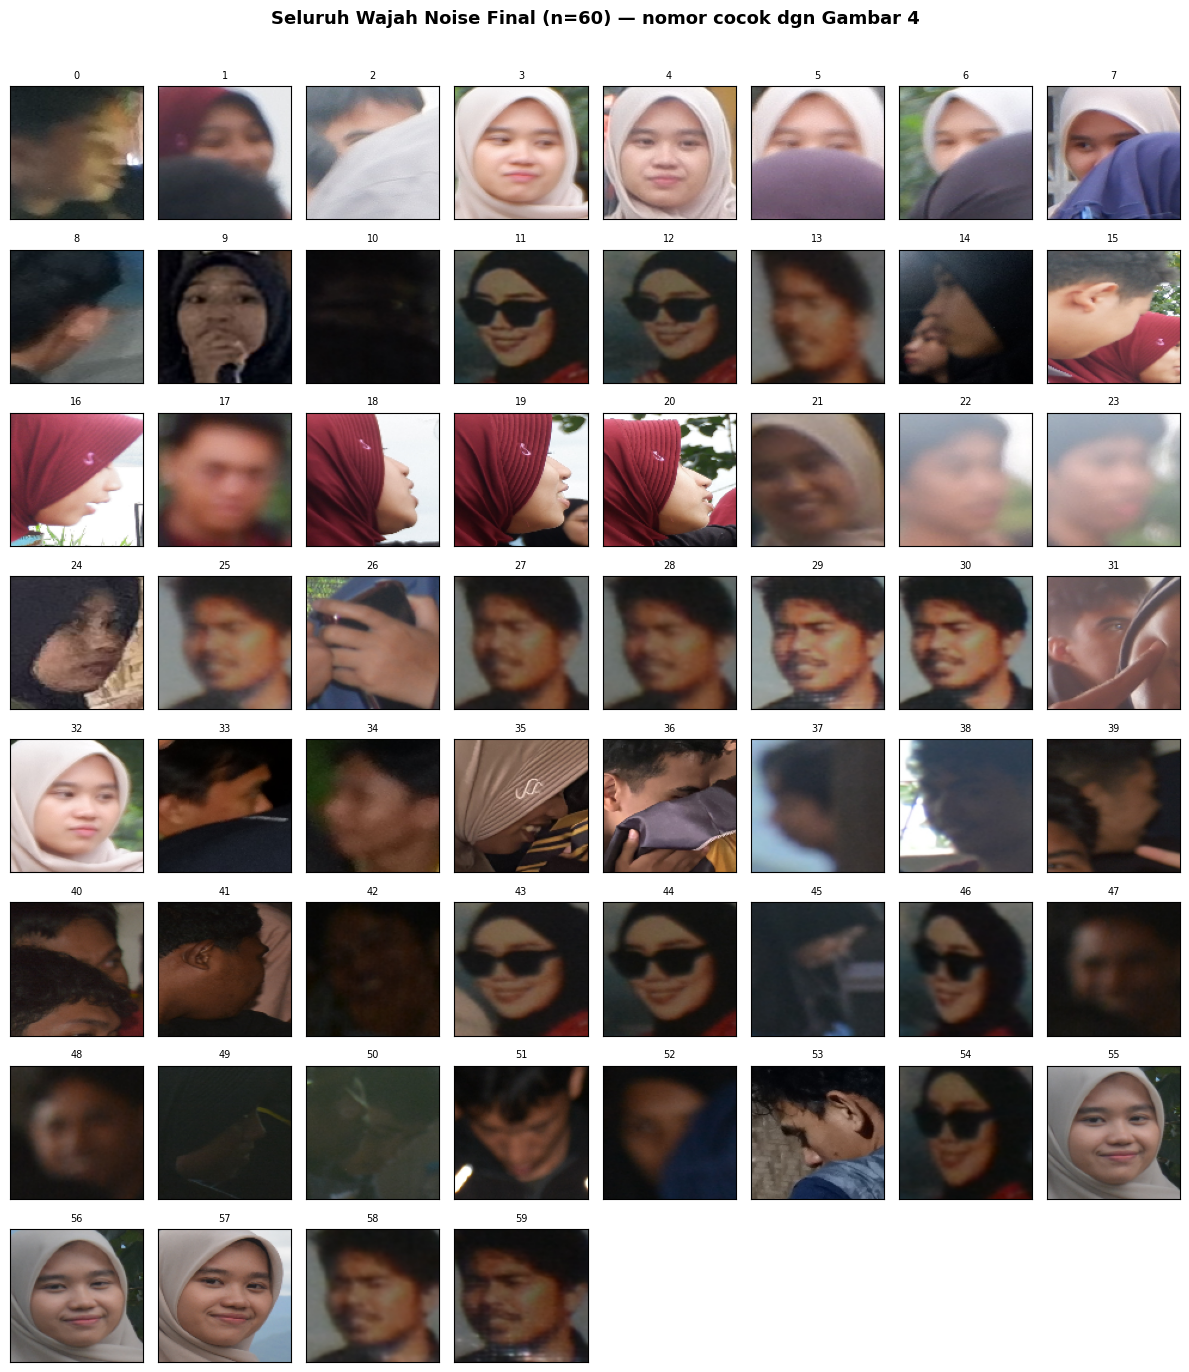

In [20]:
noise_idx = np.where(labels_E == -1)[0]
noise_order = np.sort(noise_idx)   # urutan tetap & reproducible
ranks = list(range(len(noise_order)))

print(f"Total wajah noise: {len(noise_order)}")

fig3 = render_faces(
    noise_order.tolist(), ranks=ranks, cols=8,
    title=f"Seluruh Wajah Noise Final (n={len(noise_order)}) \u2014 nomor cocok dgn Gambar 4"
)
fig3.savefig(OUTPUT_DIR / "gambar3_contact_sheet_noise.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Gambar 4 — Sebaran dengan Anotasi Nomor (pasangan Gambar 3)

In [ ]:
fig, ax = plt.subplots(figsize=(14, 12))

ax.scatter(emb_2d[mask_clust, 0], emb_2d[mask_clust, 1],
           c='#90A4AE', s=3, alpha=0.4, zorder=1, rasterized=True)

ax.scatter(emb_2d[noise_order, 0], emb_2d[noise_order, 1],
           c='#E53935', s=14, alpha=0.95, zorder=3,
           edgecolors='black', linewidths=0.4)

for rank, gi in zip(ranks, noise_order):
    ax.annotate(str(rank), (emb_2d[gi, 0], emb_2d[gi, 1]),
                fontsize=5.5, color='black', zorder=4,
                xytext=(2, 2), textcoords='offset points')

ax.set_title(
    f"Sebaran dgn Nomor Wajah Noise (n={len(noise_order)})\n"
    f"Cocokkan nomor titik di sini dgn nomor ubin di Gambar 3 utk melihat foto aslinya",
    fontsize=12, fontweight='bold'
)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.grid(alpha=0.15)

# --- Panel zoom-in otomatis: area dgn JUMLAH tetangga noise terbanyak ---
# (bukan pasangan-terdekat \u2014 metrik "rata-rata jarak k-NN" sebelumnya
# gampang tertipu oleh 1 pasang titik yg kebetulan sangat berdekatan/nyaris
# duplikat, walau pasangan itu terisolasi & bukan area yg sungguh padat.
# Dihitung ulang jadi "hitung tetangga dlm radius tetap" \u2014 metrik ini
# langsung menjawab pertanyaan yg relevan: di titik mana paling BANYAK
# noise berkumpul dlm area kecil, itulah yg bikin label bertumpuk visual.)
from scipy.spatial import cKDTree

noise_coords = emb_2d[noise_order]
span_x = emb_2d[:, 0].max() - emb_2d[:, 0].min()
span_y = emb_2d[:, 1].max() - emb_2d[:, 1].min()
search_r = max(span_x, span_y) * 0.05   # radius pencarian tetangga, 5% skala plot

tree = cKDTree(noise_coords)
neighbor_lists = tree.query_ball_point(noise_coords, r=search_r)
neighbor_counts = np.array([len(lst) - 1 for lst in neighbor_lists])  # -1: exclude diri sendiri

densest_i = int(np.argmax(neighbor_counts))
print(f"Titik terpadat: noise #{ranks[densest_i]} dgn {neighbor_counts[densest_i]} "
      f"tetangga noise lain dlm radius {search_r:.2f}")

if neighbor_counts[densest_i] >= 1:
    center = noise_coords[densest_i]
    nearby_idx = neighbor_lists[densest_i]
    nearby_coords = noise_coords[nearby_idx]
    # radius tampilan: cukup lebar utk mencakup semua tetangga di area itu + padding 40%
    view_radius = max(np.abs(nearby_coords - center).max(), search_r) * 1.4

    rect = mpatches.Rectangle((center[0] - view_radius, center[1] - view_radius),
                               2 * view_radius, 2 * view_radius,
                               fill=False, edgecolor='black', linewidth=1.3, zorder=5, linestyle='--')
    ax.add_patch(rect)

    axins = fig.add_axes([0.66, 0.08, 0.30, 0.30])
    axins.scatter(emb_2d[mask_clust, 0], emb_2d[mask_clust, 1],
                  c='#90A4AE', s=10, alpha=0.5, zorder=1, rasterized=True)
    axins.scatter(emb_2d[noise_order, 0], emb_2d[noise_order, 1],
                  c='#E53935', s=35, alpha=0.95, zorder=3,
                  edgecolors='black', linewidths=0.6)
    for rank, gi in zip(ranks, noise_order):
        axins.annotate(str(rank), (emb_2d[gi, 0], emb_2d[gi, 1]),
                        fontsize=8, color='black', zorder=4,
                        xytext=(3, 3), textcoords='offset points')
    axins.set_xlim(center[0] - view_radius, center[0] + view_radius)
    axins.set_ylim(center[1] - view_radius, center[1] + view_radius)
    axins.set_xticks([]); axins.set_yticks([])
    for spine in axins.spines.values():
        spine.set_edgecolor('black'); spine.set_linewidth(1.3)
    axins.set_title(f"Zoom: area noise terpadat ({neighbor_counts[densest_i]+1} titik)", fontsize=8)
else:
    print("Tidak ada area noise yang menumpuk (semua titik saling terpisah) \u2014 panel zoom dilewati.")

plt.savefig(OUTPUT_DIR / "gambar4_sebaran_beranotasi.png", dpi=150, bbox_inches='tight')
plt.show()

print("Catatan: kotak putus-putus di plot utama menandai area yang di-zoom di "
      "panel kanan-bawah \u2014 dipilih otomatis berdasar JUMLAH tetangga noise terbanyak.")

## 8. Ringkasan

4 gambar tersimpan ke `output_nb12/`:
1. `gambar1_sebaran_final.png` — sebaran hasil final, cluster vs noise
2. `gambar2_sebelum_sesudah_refinement.png` — S0 (pass-1) vs S1 (final), efek kontribusi utama
3. `gambar3_contact_sheet_noise.png` — seluruh wajah noise, bernomor
4. `gambar4_sebaran_beranotasi.png` — sebaran dgn nomor yang sama, utk ditelusuri balik ke Gambar 3

**Untuk sidang:** kalau penguji bertanya soal titik/wajah tertentu, tunjuk titik di
Gambar 4, baca nomornya, cari nomor yang sama di Gambar 3 \u2014 foto aslinya
langsung terlihat. Ingatkan bahwa jarak & kepadatan di plot ini ilustratif (artefak
proyeksi UMAP 2D), bukan bukti kuantitatif \u2014 bukti kuantitatif ada di Tabel IV.6.

In [22]:
print("=" * 60)
print("  RINGKASAN NB12")
print("=" * 60)
print(f"  Total wajah (inlier)  : {len(labels_E):,}")
print(f"  Cluster (S1, final)   : {n_cluster_E}")
print(f"  Noise (S1, final)     : {n_noise_E}")
print(f"  Noise (S0, pass-1)    : {n_noise_S0}")
print(f"  Output disimpan ke    : {OUTPUT_DIR}")
print("=" * 60)

  RINGKASAN NB12
  Total wajah (inlier)  : 14,790
  Cluster (S1, final)   : 139
  Noise (S1, final)     : 60
  Noise (S0, pass-1)    : 450
  Output disimpan ke    : /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb12
